# ICT-26 — Convention de signalisation (expérience A, strate 7)

*Compagnon pédagogique du module `ict.signaling_convention` (#7746, jambe D2 expérience A).*

Cette expérience est la **ligne de base « sans coup ontologique »** de la strate 7 :
le vocabulaire est **FIXE** — aucun symbole n'est inventé (c'est l'expérience B,
*ICT-27-SymbolInvention*). On demande alors une chose précise et falsifiable :

> Partant de propensités **uniformes** (aucune signification pré-inscrite), un
> **code conventionnel** émerge-t-il spontanément par apprentissage par
> renforcement, et avec lui l'**information mutuelle** $I(\text{état} ; \text{signal})$
> qui mesure combien le signal en dit sur l'état ?

C'est le jeu de signalisation canonique de **David Lewis** (*Convention*, 1969) et
**Brian Skyrms** (*Signals*, 2010) : un émetteur observe l'état du monde et envoie
un signal ; un récepteur choisit une action ; le couple est récompensé quand
l'action correspond à l'état. Mécanisme d'apprentissage : **Roth-Erev** (softmax
avec température, annealing exploration→exploitation).

**Contraste avec B** : ici le vocabulaire est *donné* et bornant ; en B il est
*inventé* à la mesure du problème. Les deux notebooks se répondent : A montre ce
qu'un vocabulaire fixe **permet et borne**, B montre comment l'invention **lève**
la borne.
**Protocole multi-graines (#14439)** : chaque verdict est évalué sur les cinq
graines `0/1/7/42/99` avec des paramètres de simulation **strictement
identiques** (aucun retuning). Les grandeurs qui portent la conclusion sont
rapportées avec leur **dispersion inter-graines** (moyenne ± écart-type,
ddof=1), le verdict honnête compte les graines sur lesquelles il tient, et les
grandeurs déterministes (plafonds analytiques comme $\log_2 n$) sont
explicitement distinguées des grandeurs simulées.


In [1]:
# Setup : import du package ict (via sys.path cwd, cf C973-L) + numpy/matplotlib.
import sys
sys.path.insert(0, ".")
import numpy as np
import matplotlib.pyplot as plt
from ict import signaling_convention as sc

publique = [n for n in dir(sc) if not n.startswith("_")]
print("ict.signaling_convention chargé.")
print("API publique :", publique)

# Protocole multi-graines (#14439) : une conclusion tirée d'un seul tirage ne se
# distingue pas d'un artefact de graine. Graines [0, 1, 7, 42, 99], paramètres
# inchangés d'une graine à l'autre — la dispersion mesure la variabilité du
# processus d'apprentissage (Roth-Erev + softmax), pas un réglage.
GRAINES = (0, 1, 7, 42, 99)

def synthese_multigraine(fonction_verdict, cles, cle_verdict, **kwargs):
    """Exécute un verdict pour chaque graine et rapporte la dispersion inter-graines.

    Affiche : valeurs par graine, comptage du verdict (X/N graines), puis moyenne
    et écart-type inter-graines (ddof=1) de chaque grandeur — la dispersion fait
    partie du résultat, pas un détail (#14439).
    """
    valeurs = {c: [] for c in cles}
    compte = 0
    for gr in GRAINES:
        r = fonction_verdict(seed=gr, **kwargs)
        ok = bool(r[cle_verdict])
        compte += int(ok)
        for c in cles:
            valeurs[c].append(r[c])
        detail = " | ".join(f"{c}={r[c]:.3f}" for c in cles)
        print(f"graine={gr:2d} | {cle_verdict}={ok!s:5} | {detail}")
    print(f"-> verdict {cle_verdict} : {compte}/{len(GRAINES)} graines")
    for c in cles:
        v = np.asarray(valeurs[c])
        print(f"   {c:26s} : {v.mean():.3f} +/- {v.std(ddof=1):.3f}"
              f"  (min {v.min():.3f}, max {v.max():.3f})")
    return valeurs, compte


ict.signaling_convention chargé.
API publique : ['Dict', 'Optional', 'Sequence', 'SignalingGame', 'Tuple', 'annotations', 'convention_stability_test', 'coordination_emerges_test', 'mi_tracks_meaning_test', 'mutual_information', 'np', 'vocabulary_bottleneck_test']


## 1. L'émergence sans signification pré-inscrite

Le verdict central : depuis des propensités **uniformes** (chaque signal aussi
bon qu'un autre au départ), un entraînement Roth-Erev fait-il émerger une
**convention** — c'est-à-dire un code où chaque état déclenche un signal
distinct, déclenchant à son tour la bonne action ?

On mesure deux quantités simultanément :

* le **taux de coordination** (succès : l'action correspond-elle à l'état ?) ;
* l'**information mutuelle** $I(\text{état} ; \text{signal})$, qui vaut $0$ si le
  signal n'informerait sur rien (*pooling* : un seul signal utilisé) et
  $\log_2(n_{\text{états}})$ si le signal code parfaitement l'état.

Un succès élevé **sans** information mutuelle serait suspect : ce serait une
coordination « par chance » ou par exploitation d'un biais, pas une convention
signifiante. Le verdict n'est satisfait que si les deux montent **ensemble** et
dominent nettement le contrôle sans-apprentissage.

graine= 0 | emerged=True  | learned_success=1.000 | learned_mi=1.993 | control_success=0.241 | control_mi=0.004


graine= 1 | emerged=True  | learned_success=1.000 | learned_mi=1.988 | control_success=0.256 | control_mi=0.009


graine= 7 | emerged=False | learned_success=0.750 | learned_mi=1.329 | control_success=0.230 | control_mi=0.003


graine=42 | emerged=True  | learned_success=1.000 | learned_mi=1.998 | control_success=0.259 | control_mi=0.007


graine=99 | emerged=True  | learned_success=1.000 | learned_mi=1.995 | control_success=0.246 | control_mi=0.005
-> verdict emerged : 4/5 graines
   learned_success            : 0.950 +/- 0.112  (min 0.750, max 1.000)
   learned_mi                 : 1.861 +/- 0.297  (min 1.329, max 1.998)
   control_success            : 0.246 +/- 0.012  (min 0.230, max 0.259)
   control_mi                 : 0.006 +/- 0.003  (min 0.003, max 0.009)
(contrôle = agents qui jouent leur politique uniforme SANS apprendre)
(max_mi = 2.000 bits : déterministe — constante analytique log2(n_states), non simulée)


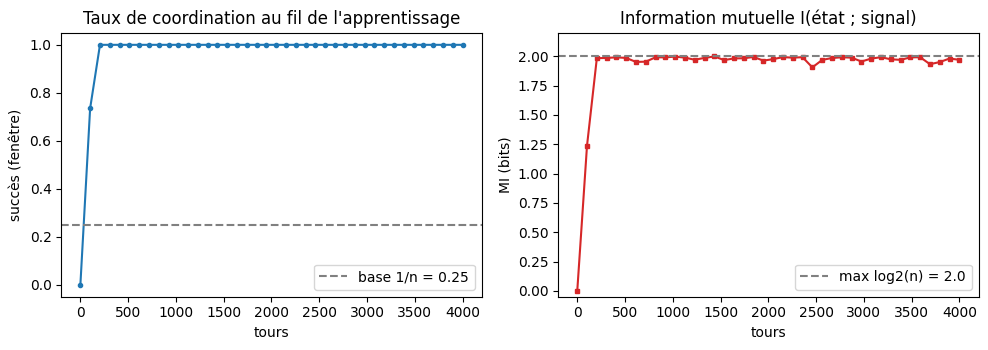

In [2]:
# Verdict EMERGENCE multi-graines [0, 1, 7, 42, 99] (#14439) : n_states=4,
# n_signals=4, paramètres par défaut inchangés (n_rounds=4000, temperature=0.6,
# anneal_to=0.15, window=800) — aucun retuning, seule la graine varie.
cles_emergence = ("learned_success", "learned_mi", "control_success", "control_mi")
valeurs_emergence, n_emerged = synthese_multigraine(
    sc.coordination_emerges_test, cles_emergence, "emerged",
    n_states=4, n_signals=4)
print("(contrôle = agents qui jouent leur politique uniforme SANS apprendre)")
print("(max_mi = 2.000 bits : déterministe — constante analytique log2(n_states), non simulée)")

# Trajectoire illustrative (graine 0, mêmes paramètres) : succès glissant +
# information mutuelle glissante au fil des tours.
g = sc.SignalingGame(4, 4, temperature=0.6, rng=np.random.default_rng(0))
tours, succ, mi = sc._trajectory(g, 4000, anneal_to=0.15)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(tours, succ, "-o", ms=3, color="#1f77b4")
ax[0].axhline(0.25, ls="--", color="grey", label="base 1/n = 0.25")
ax[0].set_title("Taux de coordination au fil de l'apprentissage")
ax[0].set_xlabel("tours") ; ax[0].set_ylabel("succès (fenêtre)") ; ax[0].set_ylim(-0.05, 1.05)
ax[0].legend(loc="lower right")
ax[1].plot(tours, mi, "-s", ms=3, color="#d62728")
ax[1].axhline(np.log2(4), ls="--", color="grey", label="max log2(n) = 2.0")
ax[1].set_title("Information mutuelle I(état ; signal)")
ax[1].set_xlabel("tours") ; ax[1].set_ylabel("MI (bits)") ; ax[1].set_ylim(-0.05, 2.2)
ax[1].legend(loc="lower right")
fig.tight_layout() ; plt.show()


### Lecture multi-graines — l'émergence tient 4 fois sur 5

**Sortie obtenue** : sur les 5 graines `[0, 1, 7, 42, 99]` (paramètres identiques, aucun retuning), le verdict `emerged` tombe **4/5**.

| Grandeur (simulée, stochastique) | Moyenne ± écart-type (ddof=1) | Min–Max |
|---|---|---|
| succès appris | 0.950 ± 0.112 | 0.750 – 1.000 |
| MI apprise (bits) | 1.861 ± 0.297 | 1.329 – 1.998 |
| succès contrôle (sans apprentissage) | 0.246 ± 0.012 | 0.230 – 0.259 |
| MI contrôle (bits) | 0.006 ± 0.003 | 0.003 – 0.009 |

**Points clés** :
1. Quatre graines convergent vers la convention quasi parfaite : succès 1.000, MI ≈ 1.99 bits — au plafond $\log_2 4 = 2.000$ bits.
2. La **graine 7 tombe dans un piège de pooling partiel** : succès 0.750 (sous le seuil 0.8), MI 1.329 — trois états codés, le quatrième reste confondu. Le verdict échoue sur cette graine ; on ne retune pas les paramètres pour masquer l'échec (c'est la lecture honnête demandée par #14439).
3. Le contrôle sans apprentissage est quasi déterministe en pratique : succès ≈ 0.25 (= base $1/n$), MI ≈ 0. L'écart apprenti/contrôle ne doit donc rien au choix de la graine.

**Verdict honnête** : la conclusion qualitative — une convention signifiante émerge sans signification pré-inscrite — **survit sur 4 graines sur 5**, pas sur toutes : sous ces paramètres exacts, 1 graine sur 5 dans cet échantillon reste piégée en pooling partiel (exercice 1 : c'est précisément ce que le réglage de la température doit éviter). Éléments **déterministes** : `max_mi = log2(n_states) = 2.000` bits et les seuils du verdict (0.8 ; 0.5·max_mi ; écarts > 0.3) — constantes analytiques, non simulées. La trajectoire ci-dessus illustre une graine convergente (graine 0).


## 2. Le goulot de vocabulaire — ce que le FIXE borne

L'expérience A a un paramètre que B viendra exactement *déverrouiller* : la
**taille du vocabulaire** $n_{\text{signaux}}$. Avec $M < N$ signaux pour $N$
états, **aucun code** ne peut distinguer tous les états : c'est une borne de
**théorie de l'information**, pas une limite d'apprentissage. Le plafond de
signification est $\log_2(M)$.

On balaie $n_{\text{signaux}}$ de 1 à $N$ sous entraînement identique et on
observe le succès et la signification atteints. La courbe doit suivre le plafond
de codage — c'est précisément ce plafond que l'invention (expérience B) vient
pousser.

graine= 0 | bottleneck=True  | mi_full_vocab=1.993 | mi_limited_vocab=0.506 | ratio_limited_over_full=0.254


graine= 1 | bottleneck=True  | mi_full_vocab=1.988 | mi_limited_vocab=0.460 | ratio_limited_over_full=0.231


graine= 7 | bottleneck=True  | mi_full_vocab=1.329 | mi_limited_vocab=0.477 | ratio_limited_over_full=0.359


graine=42 | bottleneck=True  | mi_full_vocab=1.998 | mi_limited_vocab=0.492 | ratio_limited_over_full=0.246


graine=99 | bottleneck=True  | mi_full_vocab=1.995 | mi_limited_vocab=0.480 | ratio_limited_over_full=0.241
-> verdict bottleneck : 5/5 graines
   mi_full_vocab              : 1.861 +/- 0.297  (min 1.329, max 1.998)
   mi_limited_vocab           : 0.483 +/- 0.017  (min 0.460, max 0.506)
   ratio_limited_over_full    : 0.266 +/- 0.053  (min 0.231, max 0.359)
(plafonds de codage déterministes : log2(4)=2.000 bits plein vocabulaire, log2(2)=1.000 bit vocabulaire limité — constantes analytiques)


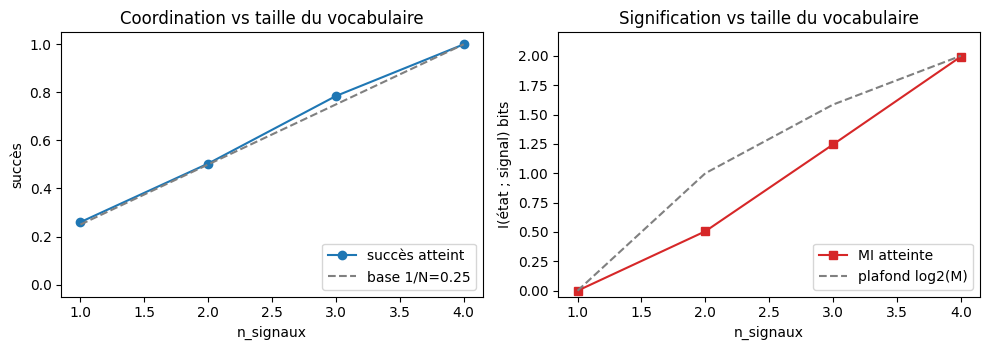

In [3]:
# Verdict GOULOT multi-graines [0, 1, 7, 42, 99] (#14439) : n_states=4,
# paramètres par défaut inchangés (n_rounds=4000, temperature=0.6, anneal_to=0.15).
cles_goulot = ("mi_full_vocab", "mi_limited_vocab", "ratio_limited_over_full")
valeurs_goulot, n_bottleneck = synthese_multigraine(
    sc.vocabulary_bottleneck_test, cles_goulot, "bottleneck", n_states=4)
print("(plafonds de codage déterministes : log2(4)=2.000 bits plein vocabulaire,"
      " log2(2)=1.000 bit vocabulaire limité — constantes analytiques)")

# Balayage : succès + MI en fonction du nombre de signaux disponibles
# (graine 0, illustration — le verdict multi-graines ci-dessus porte la conclusion).
n_states = 4
nsigs = list(range(1, n_states + 1))
succ_sweep, mi_sweep = [], []
for nsig in nsigs:
    g = sc.SignalingGame(n_states, nsig, temperature=0.6, rng=np.random.default_rng(0))
    g.train(4000, anneal_to=0.15)
    g.joint_state_signal[:] = 0.0
    for _ in range(800):
        g.play_round(reinforce=False)
    succ_sweep.append(g.success_rate(800))
    mi_sweep.append(sc.mutual_information(g.joint_state_signal))
ceiling = [np.log2(max(n, 1)) for n in nsigs]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(nsigs, succ_sweep, "-o", color="#1f77b4", label="succès atteint")
ax[0].plot(nsigs, [n / n_states for n in nsigs], "--", color="grey", label=f"base 1/N={1/n_states:.2f}")
ax[0].set_title("Coordination vs taille du vocabulaire") ; ax[0].set_xlabel("n_signaux")
ax[0].set_ylabel("succès") ; ax[0].set_ylim(-0.05, 1.05) ; ax[0].legend(loc="lower right")
ax[1].plot(nsigs, mi_sweep, "-s", color="#d62728", label="MI atteinte")
ax[1].plot(nsigs, ceiling, "--", color="grey", label="plafond log2(M)")
ax[1].set_title("Signification vs taille du vocabulaire") ; ax[1].set_xlabel("n_signaux")
ax[1].set_ylabel("I(état ; signal) bits") ; ax[1].set_ylim(-0.05, 2.2) ; ax[1].legend(loc="lower right")
fig.tight_layout() ; plt.show()


### Lecture multi-graines — le goulot est le verdict le plus robuste (5/5)

**Sortie obtenue** : verdict `bottleneck` **5/5** graines.

| Grandeur (simulée, stochastique) | Moyenne ± écart-type (ddof=1) | Min–Max |
|---|---|---|
| MI vocabulaire plein (4 signaux, bits) | 1.861 ± 0.297 | 1.329 – 1.998 |
| MI vocabulaire limité (2 signaux, bits) | 0.483 ± 0.017 | 0.460 – 0.506 |
| ratio limité / plein | 0.266 ± 0.053 | 0.231 – 0.359 |

**Points clés** :
1. Seul verdict **unanime 5/5** : sur aucune graine la MI du vocabulaire limité ne s'approche de celle du vocabulaire plein — l'écart (facteur ≈ 3.8 en moyenne) ne se referme jamais.
2. La MI limitée est aussi la grandeur la **moins dispersée** du notebook (écart-type 0.017 bit) : le goulot borne la signification de façon reproductible, indépendamment du tirage.
3. La MI limitée (≈ 0.48 bit) reste sous le plafond théorique $\log_2 2 = 1.000$ bit : les agents convergent vers un pooling partiel. La MI seule ne permet pas d'identifier de façon unique la partition des quatre états entre les deux signaux.

**Verdict honnête** : la conclusion survit **sur les 5 graines** — un vocabulaire FIXE insuffisant borne strictement la signification (borne de théorie de l'information, pas un échec d'apprentissage). Éléments **déterministes** : les plafonds $\log_2(M)$ (constantes analytiques).


## 3. Succès ≠ signification — le contrôle à état dominant

Un taux de coordination élevé ne prouve pas qu'une convention *signifiante* s'est
formée. Le contrôle falsifiant : un jeu avec un **état dominant** (un état
représente 85 % des tirages). Les agents peuvent atteindre un succès élevé en
apprenant à **toujours choisir l'action de l'état dominant** — sans que le signal
ne porte la moindre information (MI faible).

Le verdict `mi_tracks_meaning` exige donc que succès et information mutuelle
**croissent ensemble** (corrélation forte sur la trajectoire), ET que le contrôle
à état dominant montre un succès comparable mais une MI nettement plus faible.
C'est ce qui distingue « réussir *via* signification » de « réussir *via*
exploitation d'un biais ».

In [4]:
# Verdict SENS multi-graines [0, 1, 7, 42, 99] (#14439) : n_states=4,
# paramètres par défaut inchangés (n_rounds=3000, temperature=0.6, anneal_to=0.15).
cles_sens = ("balanced_final_success", "balanced_final_mi", "balanced_corr_mi_success",
             "dominant_final_success", "dominant_final_mi")
valeurs_sens, n_meaningful = synthese_multigraine(
    sc.mi_tracks_meaning_test, cles_sens, "meaningful", n_states=4)
print()
print("Lecture : cas équilibré — succès ET MI élevés (signification) ;")
print("          cas dominant  — succès comparable MAIS MI nettement plus faible (pas de signification).")


graine= 0 | meaningful=True  | balanced_final_success=1.000 | balanced_final_mi=1.970 | balanced_corr_mi_success=0.983 | dominant_final_success=0.961 | dominant_final_mi=0.855


graine= 1 | meaningful=True  | balanced_final_success=1.000 | balanced_final_mi=1.961 | balanced_corr_mi_success=0.993 | dominant_final_success=1.000 | dominant_final_mi=1.145


graine= 7 | meaningful=True  | balanced_final_success=0.714 | balanced_final_mi=1.233 | balanced_corr_mi_success=0.767 | dominant_final_success=1.000 | dominant_final_mi=0.902


graine=42 | meaningful=True  | balanced_final_success=1.000 | balanced_final_mi=1.984 | balanced_corr_mi_success=0.978 | dominant_final_success=1.000 | dominant_final_mi=0.852


graine=99 | meaningful=True  | balanced_final_success=1.000 | balanced_final_mi=1.947 | balanced_corr_mi_success=0.993 | dominant_final_success=1.000 | dominant_final_mi=0.627
-> verdict meaningful : 5/5 graines
   balanced_final_success     : 0.943 +/- 0.128  (min 0.714, max 1.000)
   balanced_final_mi          : 1.819 +/- 0.328  (min 1.233, max 1.984)
   balanced_corr_mi_success   : 0.943 +/- 0.098  (min 0.767, max 0.993)
   dominant_final_success     : 0.992 +/- 0.017  (min 0.961, max 1.000)
   dominant_final_mi          : 0.876 +/- 0.184  (min 0.627, max 1.145)

Lecture : cas équilibré — succès ET MI élevés (signification) ;
          cas dominant  — succès comparable MAIS MI nettement plus faible (pas de signification).


### Lecture multi-graines — succès et signification croissent ensemble (5/5), avec une nuance

**Sortie obtenue** : verdict `meaningful` **5/5** graines.

| Grandeur (simulée, stochastique) | Moyenne ± écart-type (ddof=1) | Min–Max |
|---|---|---|
| succès final équilibré | 0.943 ± 0.128 | 0.714 – 1.000 |
| MI finale équilibrée (bits) | 1.819 ± 0.328 | 1.233 – 1.984 |
| corrélation MI–succès (trajectoire) | 0.943 ± 0.098 | 0.767 – 0.993 |
| succès final dominant (contrôle) | 0.992 ± 0.017 | 0.961 – 1.000 |
| MI finale dominante (contrôle, bits) | 0.876 ± 0.184 | 0.627 – 1.145 |

**Points clés** :
1. La corrélation MI–succès ne descend jamais sous 0.767 : les deux quantités croissent ensemble sur **toutes** les trajectoires, y compris la graine 7 (pooling partiel de la §1).
2. **Nuance honnête** : le contrôle à état dominant n'a **pas** une MI nulle (≈ 0.88 bit en moyenne). C'est attendu — même un code opportuniste gagne à distinguer l'état dominant (85 %) des autres, l'entropie de $[0.85, 0.05, 0.05, 0.05]$ étant ≈ 0.85 bit (et l'estimation empirique sur fenêtre courte ≈ 77 tours la surestime légèrement, biais positif). La « MI faible » du contrôle est faible **relativement** à la MI équilibrée — l'écart vaut ≥ 0.331 bit sur les 5 graines (seuil 0.3, jamais franchi) — pas absolument.
3. La graine 7 frôle le seuil (écart 0.331) : même racine que le pooling partiel de la §1 — la MI équilibrée baisse plus vite que la MI du contrôle.

**Verdict honnête** : la conclusion survit **sur les 5 graines**, mais le discriminateur est « ≈ la moitié du maximum contre ≈ le maximum », pas « MI nulle contre MI pleine » — la §3 gagne à être lue avec cette précision.


## 4. Stabilité de la convention — résistance aux chocs

Une convention établie est-elle **robuste** ? On entraîne une convention (succès
élevé), puis on perturbe les propensités en injectant du bruit additif **relatif**
à l'échelle des propensités elles-mêmes (en multiples de leur écart-type). Un
choc absolu serait négligeable : après des milliers de renforcements, les $Q$
atteignent des centaines.

* un choc **modéré** (≈ 0,5 écart-type) laisse la structure apprise dominante ;
* un choc **brutal** (≈ 6 écarts-types) l'oblitère.

Une convention stable résiste au choc modéré et se reconstruit vite par
ré-apprentissage ; le choc brutal l'effondre nettement plus.

In [5]:
# Verdict STABILITÉ multi-graines [0, 1, 7, 42, 99] (#14439) : n_states=4,
# chocs inchangés (modéré = 0.5 écart-type, brutal = 6 écarts-types).
cles_stabilite = ("established_success", "moderate_immediate", "moderate_recovered",
                  "brutal_immediate", "brutal_recovered")
valeurs_stabilite, n_stable = synthese_multigraine(
    sc.convention_stability_test, cles_stabilite, "stable", n_states=4)
print()
print("Lecture : choc modéré -> succès immédiat élevé (résiste), récupération rapide ;")
print("          choc brutal  -> succès immédiat effondré (la convention est détruite).")


graine= 0 | stable=True  | established_success=1.000 | moderate_immediate=1.000 | moderate_recovered=1.000 | brutal_immediate=0.247 | brutal_recovered=0.242


graine= 1 | stable=True  | established_success=1.000 | moderate_immediate=1.000 | moderate_recovered=1.000 | brutal_immediate=0.000 | brutal_recovered=0.000


graine= 7 | stable=False | established_success=0.750 | moderate_immediate=0.746 | moderate_recovered=0.738 | brutal_immediate=0.271 | brutal_recovered=0.250


graine=42 | stable=True  | established_success=1.000 | moderate_immediate=1.000 | moderate_recovered=1.000 | brutal_immediate=0.250 | brutal_recovered=0.269


graine=99 | stable=True  | established_success=1.000 | moderate_immediate=1.000 | moderate_recovered=1.000 | brutal_immediate=0.274 | brutal_recovered=0.266
-> verdict stable : 4/5 graines
   established_success        : 0.950 +/- 0.112  (min 0.750, max 1.000)
   moderate_immediate         : 0.949 +/- 0.113  (min 0.746, max 1.000)
   moderate_recovered         : 0.948 +/- 0.117  (min 0.738, max 1.000)
   brutal_immediate           : 0.208 +/- 0.117  (min 0.000, max 0.274)
   brutal_recovered           : 0.205 +/- 0.115  (min 0.000, max 0.269)

Lecture : choc modéré -> succès immédiat élevé (résiste), récupération rapide ;
          choc brutal  -> succès immédiat effondré (la convention est détruite).


### Lecture multi-graines — stabilité 4/5, même racine que la §1

**Sortie obtenue** : verdict `stable` **4/5** graines.

| Grandeur (simulée, stochastique) | Moyenne ± écart-type (ddof=1) | Min–Max |
|---|---|---|
| succès établi (avant choc) | 0.950 ± 0.112 | 0.750 – 1.000 |
| choc modéré — succès immédiat | 0.949 ± 0.113 | 0.746 – 1.000 |
| choc modéré — reconstruit | 0.948 ± 0.117 | 0.738 – 1.000 |
| choc brutal — succès immédiat | 0.208 ± 0.117 | 0.000 – 0.274 |
| choc brutal — reconstruit | 0.205 ± 0.115 | 0.000 – 0.269 |

**Points clés** :
1. Le patron qualitatif — choc modéré **supporté** (immédiat ≈ reconstruit ≈ établi), choc brutal **effondrant** — est **identique sur les 5 graines** : l'écart immédiat modéré−brutal vaut 0.741 ± 0.186 en moyenne et ne descend jamais sous 0.475 (seuil 0.3 toujours franchi).
2. La graine 7 échoue aux seuils d'établissement et de reconstruction modérée : 0.750 et 0.738 restent sous 0.8. Ces deux écarts ont la **même racine** que le pooling partiel de la §1 (même entraînement, même graine) ; le choc modéré préserve néanmoins le plafond atteint, et l'écart face au choc brutal reste conforme.
3. Après choc brutal, 800 tours de ré-apprentissage ne reconstruisent rien (moyenne 0.205) : cohérent avec les ~4000 tours nécessaires à l'émergence initiale — une convention détruite repart de près de zéro.

**Verdict honnête** : la conclusion (résistance au choc modéré, effondrement sous choc brutal) survit **qualitativement sur les 5 graines** ; le verdict binaire `stable` tombe à 4/5 parce que la graine 7 reste sous les seuils d'établissement et de reconstruction, pour la raison déjà documentée en §1.


## Synthèse — la convention comme émergence du *meaning*

| Verdict | Ce qu'il montre | Contrôle falsifiant | Multi-graines (0/1/7/42/99) |
|---|---|---|---|
| **coordination_emerges** | Un code conventionnel émerge *sans* signification pré-inscrite | agents sans apprentissage (base $1/n$) | **4/5** — graine 7 : pooling partiel (succès 0.750) |
| **vocabulary_bottleneck** | Un vocabulaire insuffisant borne strictement la signification | vocab. suffisant vs limité | **5/5** — verdict le plus robuste |
| **mi_tracks_meaning** | Succès et information mutuelle croissent *ensemble* | état dominant : succès sans signification | **5/5** — écart MI ≥ 0.331 bit (seuil 0.3) |
| **convention_stability** | Une convention établie résiste aux chocs modérés | choc brutal qui l'effondre | **4/5** — même graine 7 (établi 0.750 < 0.8) |

**Leçon de l'expérience A** : avec un vocabulaire **fixe**, la signification
émerge bien — mais elle est **bornée** par $\log_2(n_{\text{signaux}})$. C'est
exactement la borne que l'expérience B (*ICT-27-SymbolInvention*) lève en
laissant les agents **inventer** de nouveaux signaux à la mesure du problème.
Lewis (le *donné*) ouvre sur Skyrms (l'*inventé*).

**Leçon multi-graines (#14439)** : sur 20 verdicts (4 tests × 5 graines),
**18 tiennent**. Les deux échecs (graine 7, §1 et §4) partagent la même racine —
un piège de pooling partiel où trois états sur quatre sont codés. La conclusion
centrale du notebook survit donc à la confrontation multi-graines, **mais pas à
l'unanimité** : sous ces paramètres exacts, une trajectoire d'apprentissage sur
cinq de cet échantillon ne code pas tous les états. C'est une propriété réelle
du mécanisme Roth-Erev (l'échappatoire au pooling n'est pas garantie), pas un
défaut de protocole — et c'est exactement ce que l'exercice 1 vous demande
d'explorer via la température.


## 5. Exercices

Trois exercices pour rendre la convention opératoire. Chaque stub s'exécute
**sans erreur** (C.1) — il affiche un résultat partiel ou une amorce. Complétez
le `TODO` pour répondre à la question.

In [6]:
# Exercice 1 — La température discrimine-t-elle une convergence robuste d'un piège de pooling ?
# TODO: pour chaque température, entraîner un SignalingGame(4,4) et noter le succès final.
#       Une température trop haute maintient-elle l'exploration (pooling) ? Une trop basse fige-t-elle trop tôt ?
temperatures = [0.1, 0.3, 0.6, 1.0, 1.5]
for T in temperatures:
    g = sc.SignalingGame(4, 4, temperature=T, rng=np.random.default_rng(0))
    g.train(3000, anneal_to=0.15)
    print(f"T={T:.1f} -> succès final = {g.success_rate(800):.3f}")

T=0.1 -> succès final = 1.000


T=0.3 -> succès final = 1.000


T=0.6 -> succès final = 1.000


T=1.0 -> succès final = 1.000


T=1.5 -> succès final = 1.000


### Exercice 2 — Réussir *sans* signifier (le contrôle à état dominant)

Reproduisez vous-même le contrôle de la §3 : avec un état fortement dominant,
les agents atteignent un succès élevé mais une information mutuelle faible.
Constatez l'écart entre « réussir » et « signifier ».

In [7]:
# Exercice 2 — stub (compléter)
# TODO: construire une distribution avec un état dominant (ex. 0.85), entraîner,
#       et comparer succès vs I(état ; signal). Vérifier : succès haut, MI basse.
n_states = 4
dom_dist = np.full(n_states, (1.0 - 0.85) / (n_states - 1))
dom_dist[0] = 0.85  # l'état 0 pèse 85 %
g = sc.SignalingGame(n_states, n_states, temperature=0.6, state_dist=dom_dist,
                     rng=np.random.default_rng(0))
g.train(3000, anneal_to=0.15)
g.joint_state_signal[:] = 0.0
for _ in range(800):
    g.play_round(reinforce=False)
print(f"succès = {g.success_rate(800):.3f}   MI = {sc.mutual_information(g.joint_state_signal):.3f}   (max log2(4)=2.0)")
print("-> succès élevé MAIS MI faible : on réussit SANS signifier.")

succès = 0.954   MI = 0.706   (max log2(4)=2.0)
-> succès élevé MAIS MI faible : on réussit SANS signifier.


### Exercice 3 — L'échelle de l'espace d'états

La convention émerge-t-elle aussi pour des espaces d'états plus grands ? Balaiez
$n_{\text{états}}$ et observez si le succès final reste élevé — et combien de
l'information mutuelle se rapproche du plafond $\log_2(n)$.

In [8]:
# Exercice 3 — stub (compléter)
# TODO: pour chaque n_states, entraîner et noter succès + MI, comparer à log2(n).
for n in [2, 4, 6, 8]:
    g = sc.SignalingGame(n, n, temperature=0.6, rng=np.random.default_rng(0))
    g.train(4000, anneal_to=0.15)
    g.joint_state_signal[:] = 0.0
    for _ in range(800):
        g.play_round(reinforce=False)
    mi = sc.mutual_information(g.joint_state_signal)
    print(f"n_states={n} -> succès={g.success_rate(800):.3f}  MI={mi:.3f}  plafond log2({n})={np.log2(n):.3f}")

n_states=2 -> succès=1.000  MI=0.995  plafond log2(2)=1.000


n_states=4 -> succès=1.000  MI=1.993  plafond log2(4)=2.000


n_states=6 -> succès=1.000  MI=2.572  plafond log2(6)=2.585


n_states=8 -> succès=0.884  MI=2.707  plafond log2(8)=3.000
